In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Data
df = pd.read_csv(r"E:\infotact solution project2\hotel_bookings.csv")
print(df)

               hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27   
2                    July     

In [4]:
# View data
print(df.head())
print(df.info())


          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [5]:
# Missing Values
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [10]:
df['children'] = df['children'].fillna(0)
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)


In [11]:
df.fillna({'children': 0, 'agent': 0, 'company': 0}, inplace=True)


In [12]:
# Feature Engineering
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']


In [13]:
# Cancellation Rate
cancel_rate = df['is_canceled'].mean()*100
print("Cancellation Rate:", cancel_rate)


Cancellation Rate: 37.041628277075134


In [15]:
# Monthly Booking Trend
monthly = df.groupby('arrival_date_month')['hotel'].count()


In [16]:
# ADR Trend
adr = df.groupby('arrival_date_month')['adr'].mean()


In [38]:
# Save Cleaned Data
df.to_csv("cleaned_hotel_bookings.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


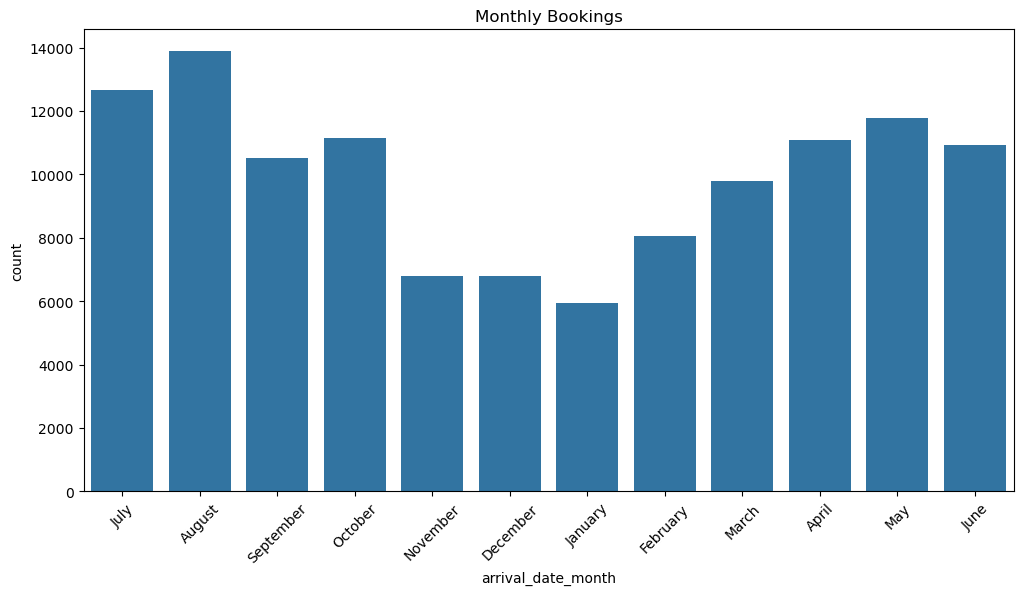

In [27]:
# Charts
plt.figure(figsize=(12,6))
sns.countplot(x='arrival_date_month', data=df)
plt.xticks(rotation=45)
plt.title("Monthly Bookings")
plt.savefig("monthly booking.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14376\1110029582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_canceled', y='adr', data=df, palette="Set2")


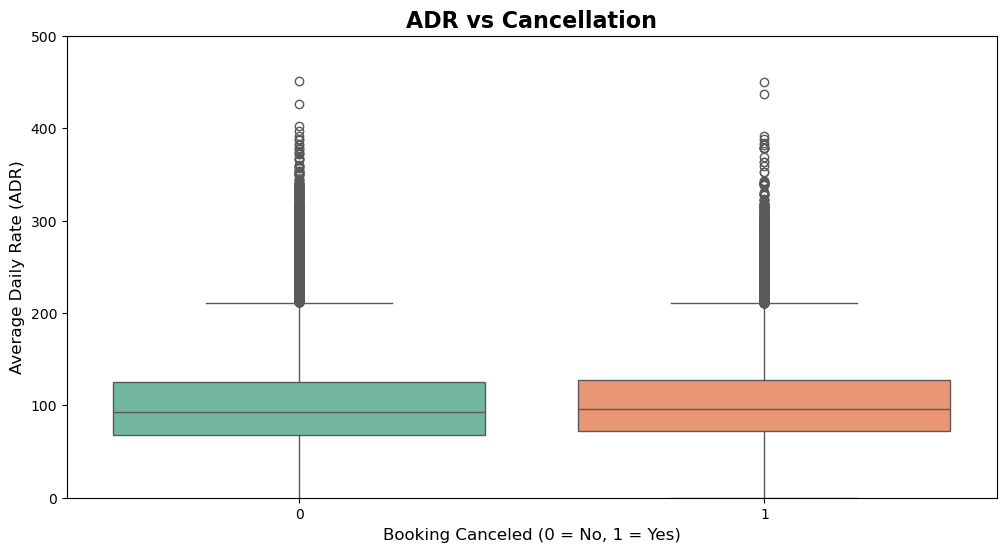

In [28]:
plt.figure(figsize=(12,6))
sns.boxplot(x='is_canceled', y='adr', data=df, palette="Set2")
plt.title("ADR vs Cancellation", fontsize=16, fontweight='bold')
plt.xlabel("Booking Canceled (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Average Daily Rate (ADR)", fontsize=12)
plt.ylim(0, 500)  # optional: cap extreme outliers for readability
plt.savefig("adr_vs_cancellation.png", dpi=300, bbox_inches='tight')
plt.show()


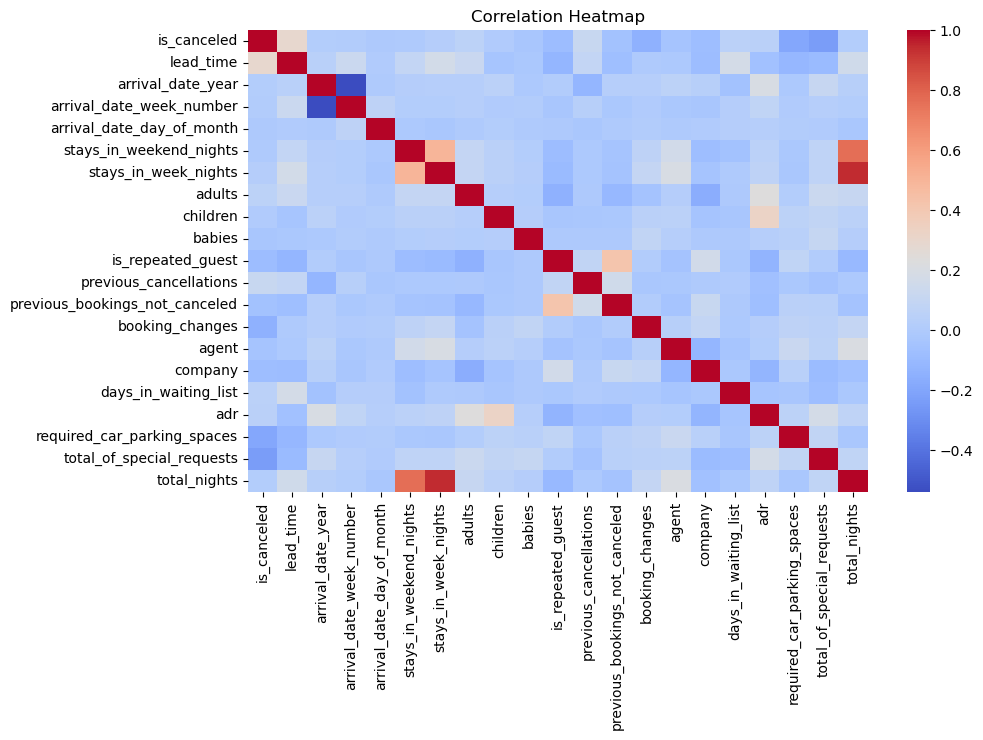

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("correlation heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier


In [31]:
# Encode categorical columns
df_ml = df.copy()

In [32]:
for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col].astype(str))


In [33]:
X = df_ml.drop('is_canceled', axis=1)
y = df_ml['is_canceled']


In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [35]:
model = RandomForestClassifier()
model.fit(X_train,y_train)


RandomForestClassifier()

In [36]:
pred = model.predict(X_test)


In [37]:
print("Accuracy:", accuracy_score(y_test,pred))
print(classification_report(y_test,pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14907
           1       1.00      1.00      1.00      8971

    accuracy                           1.00     23878
   macro avg       1.00      1.00      1.00     23878
weighted avg       1.00      1.00      1.00     23878

